# CNN实现猫狗分类

## 数据集分割

In [3]:

import os
import shutil
import random
 
def split_files(input_folder, train_folder, val_folder, split_ratio=0.8):
    # 检查输入文件夹是否存在
    if not os.path.exists(input_folder):
        print(f"输入文件夹 {input_folder} 不存在！")
        return
    
    # 创建训练集和验证集文件夹（如果不存在）
    if not os.path.exists(train_folder):
        os.makedirs(train_folder)
    if not os.path.exists(val_folder):
        os.makedirs(val_folder)
    
    # 存储所有文件的路径
    all_files = []
    
    # 遍历输入文件夹及其子文件夹
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            all_files.append(os.path.join(root, file))
    
    # 打乱文件列表
    random.shuffle(all_files)
    
    # 计算分割点
    split_index = int(len(all_files) * split_ratio)
    print(len(all_files))
    print(split_index)
    
    # 创建训练集文件列表和验证集文件列表
    train_files = all_files[:split_index]
    val_files = all_files[split_index:]
    print(len(train_files))
    
    # 创建目标文件夹结构（如果需要）
    def create_target_structure(file_path, target_base):
        rel_path = os.path.relpath(file_path, input_folder)
        target_dir = os.path.join(target_base, os.path.dirname(rel_path))
        if not os.path.exists(target_dir):
            os.makedirs(target_dir)
        return target_dir
    
    # 将文件复制到相应的文件夹中
    for file_path in train_files:
        target_dir = create_target_structure(file_path, train_folder)
        shutil.copy2(file_path, os.path.join(target_dir, os.path.basename(file_path)))
    
    for file_path in val_files:
        target_dir = create_target_structure(file_path, val_folder)
        shutil.copy2(file_path, os.path.join(target_dir, os.path.basename(file_path)))
    
    print(f"已将文件按照 {split_ratio*100}% 训练集和 {100 - split_ratio*100}% 验证集的比例拆分完毕。")
# 使用示例
input_folder = 'D:/GitHub/Fanghui-Lang/mechine_learning2024/DogOrCat_trains'
train_folder = 'D:/GitHub/Fanghui-Lang/mechine_learning2024/trains_dogorcat'
val_folder = 'D:/GitHub/Fanghui-Lang/mechine_learning2024/val_dogorcat'

split_files(input_folder, train_folder, val_folder, split_ratio=0.8)  # 4:1 拆分


1032
825
825
已将文件按照 80.0% 训练集和 20.0% 验证集的比例拆分完毕。


## 训练1

## 训练过程

In [2]:
import os  
import cv2  
import numpy as np  
import random
import tqdm
import tensorflow
from PIL import Image

input_folder = 'DogOrCat_trains'
train_folder = 'trains_dogorcat'
val_folder = 'val_dogorcat'

 
#todo:创建一个cnn模型
def define_cnn_model():
    #使用序列模型
    model = tensorflow.keras.models.Sequential()
    #卷积层
    model.add(tensorflow.keras.layers.Conv2D(32, (3,3), activation="relu",
                    kernel_initializer='he_uniform',
                    padding="same",
                    input_shape=(200,200,3)))
    #最大池化层
    model.add(tensorflow.keras.layers.MaxPooling2D((2,2)))
    #Flatten 层
    model.add(tensorflow.keras.layers.Flatten())
    #全连接层
    model.add(tensorflow.keras.layers.Dense(128, activation="relu",kernel_initializer='he_uniform' ))
    model.add(tensorflow.keras.layers.Dense(1, activation="sigmoid"))#输出层0，1，sigmoid模型实现输出值0~1之间，分别代表猫狗
 
    #编译模型
    opt = tensorflow.keras.optimizers.SGD(lr=0.001, momentum=0.9)#优化器，随机梯度下降，为模型找到最佳的参数
    model.compile(optimizer=opt,
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
    return model
#打印模型图片
model = define_cnn_model()
tensorflow.keras.utils.plot_model(model,
           to_file='cnn_model.png',)

def list_all_files(directory):
    # 初始化一个空列表来存储文件路径
    files = []
    
    # 遍历目录中的所有项
    for root, dirs, filenames in os.walk(directory):
        # 遍历每个文件名
        for filename in filenames:
            # 构建文件的完整路径
            file_path = os.path.join(root, filename)
            # 将文件路径添加到列表中
            files.append(file_path)
    
    return files

 
#训练模型
def train_cnn_model():
    #实例化模型
    model = define_cnn_model()
    #创建图片生成器,产生图片并输入
    datagen = tensorflow.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 225.0)
    train_generator = datagen.flow_from_directory(
        ('trains_dogorcat/CAT','trains_dogorcat/DOG'),
        class_mode='binary',
        batch_size=64,  #一次产生并输入64张图片
        target_size=(200, 200)  #缩放图片为200x200，和输入图片大小相同！！！
        )
    val_generator = datagen.flow_from_directory(
        ('val_dogorcat/CAT','val_dogorcat/DOG'),
        class_mode='binary',
        batch_size=64,  #一次产生并输入64张图片
        target_size=(200, 200)  #缩放图片为200x200，和输入图片大小相同！！！
        )
   #训练模型
    model.fit_generator(train_generator,
                        steps_per_epoch=len(train_generator),
                        epochs=20,
                        validation_data=val_generator,
                        validation_steps=50,
                        verbose=1 )

#定义函数读取测试文件夹中的照片
def read_random_image():
    folder = val_folder
    file_path = random.choice(list_all_files(val_folder))
    print(file_path)
    pil_im = Image.open(file_path, 'r')
    return pil_im
 
# 使用模型对读取出的图片进行预测
def get_predict(pil_im, model):
    #对图片进行缩放
    pil_im = pil_im.resize((200,200)) # 这里很重要，要符合后面输入图片规定的大小
    #将格式转换为 numpy array 格式
    array_im = np.asarray(pil_im)
    array_im = np.expand_dims(array_im, axis=0)
    #对图片进行预测
    result = model.predict(array_im)
    if result[0][0] > 0.5:
        print("预测结果是：狗")
    else:
        print("预测结果是：猫")
 
pil_im = read_random_image()
get_predict(pil_im, model)
pil_im.show(np.asarray(pil_im)) # 显示随机选取的照片


Failed to import pydot. You must install pydot and graphviz for `pydotprint` to work.
val_dogorcat\CAT\364.jpg
预测结果是：狗


## 训练2

824
207
Epoch 1/20
164/164 [==============================] - 34s 209ms/step - loss: 9015.6051 - acc: 0.5707 - val_loss: 3909.0419 - val_acc: 0.4585
Epoch 2/20
164/164 [==============================] - 32s 193ms/step - loss: 2335.8178 - acc: 0.5793 - val_loss: 4376.6322 - val_acc: 0.3610
Epoch 3/20
164/164 [==============================] - 31s 191ms/step - loss: 664.0483 - acc: 0.5415 - val_loss: 249.9519 - val_acc: 0.4390
Epoch 4/20
164/164 [==============================] - 32s 193ms/step - loss: 230.1745 - acc: 0.5878 - val_loss: 99.8587 - val_acc: 0.6049
Epoch 5/20
164/164 [==============================] - 31s 186ms/step - loss: 124.5277 - acc: 0.6451 - val_loss: 133.3279 - val_acc: 0.6000
Epoch 6/20
164/164 [==============================] - 33s 202ms/step - loss: 25.6814 - acc: 0.8659 - val_loss: 96.4455 - val_acc: 0.5805
Epoch 7/20
164/164 [==============================] - 35s 212ms/step - loss: 17.4508 - acc: 0.8866 - val_loss: 164.2062 - val_acc: 0.4634
Epoch 8/20
164/164 

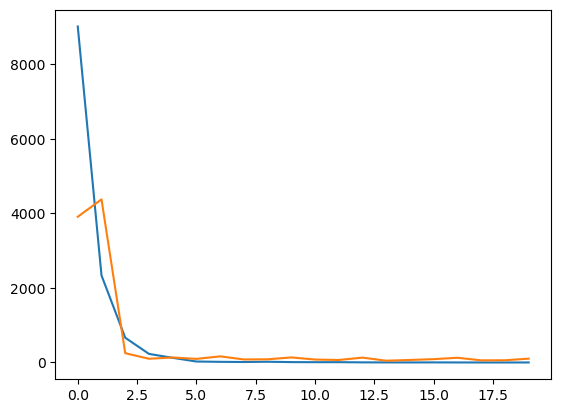

In [4]:
import json  
import os  
import cv2  
import numpy as np  
from sklearn.model_selection import train_test_split  
from sklearn.metrics import accuracy_score  
import tensorflow
  
# 数据根目录  
data_root = 'trains\DogOrCat_trains'  # 替换为您的数据根目录路径  
  
# 初始化特征和标签列表  
X = []  # 存储图像特征  
y = []  # 存储标签（0表示猫，1表示狗）  
  
# 遍历数据根目录下的所有文件夹  
for sub_folder in os.listdir(data_root):  
    folder_path = os.path.join(data_root, sub_folder)  
    if not os.path.isdir(folder_path):  
        continue  # 跳过非文件夹项  
      
    # 遍历文件夹下的所有JSON文件  
    for json_file in os.listdir(folder_path):  
        if json_file.endswith('.json'):  
            json_path = os.path.join(folder_path, json_file)  
              
            # 读取JSON文件  
            with open(json_path, 'r') as f:  
                data = json.load(f)  
              
            # 提取图像路径  
            image_path = os.path.join(folder_path, data['imagePath'])  
            # print(image_path)
              
            # 读取图像  
            image = cv2.imread(image_path)  
            if image is None:  
                print(f"Warning: Unable to read image at {image_path}")  
                continue  # 跳过无法读取的图像  
              
            # 转换为灰度图像并调整大小（这里假设调整为200x200）  
            gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  
            resized_image = cv2.resize(gray_image, (200, 200))  
              
            # 将特征添加到列表中  
            X.append(resized_image)  
              
            # 根据flags确定标签  
            if data['flags']['cat']:
                # print(data['flags']['cat'])  
                label = 0  # 猫  
            elif data['flags']['dog']:  
                label = 1  # 狗  
            else:  
                # 如果flags中的cat和dog都不是true，则打印警告并跳过该图像  
                print(f"Warning: Unexpected flags in {json_path}: cat={data['flags']['cat']}, dog={data['flags']['dog']}")  
                continue  
              
            # 将标签添加到列表中  
            y.append(label)  
  
# 将特征和标签转换为NumPy数组  
X = np.asarray(X) 
X = np.expand_dims(X,axis=-1)
y = np.asarray(y) 
y = np.expand_dims(y,axis=-1)


# 拆分数据集为训练集和测试集  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)  

print(len(X_train))
print(len(X_test))

#todo:创建一个cnn模型
def define_cnn_model():
    #使用序列模型
    model = tensorflow.keras.models.Sequential()
    #卷积层
    model.add(tensorflow.keras.layers.Conv2D(32, (3,3), activation="relu",
                    kernel_initializer='he_uniform',
                    padding="same",
                    input_shape=(200,200,1)))
    #最大池化层
    model.add(tensorflow.keras.layers.MaxPooling2D((2,2)))
    #Flatten 层
    model.add(tensorflow.keras.layers.Flatten())
    #全连接层
    model.add(tensorflow.keras.layers.Dense(128, activation="relu",kernel_initializer='he_uniform' ))
    model.add(tensorflow.keras.layers.Dense(1, activation="sigmoid"))#输出层0，1，sigmoid模型实现输出值0~1之间，分别代表猫狗
 
    #编译模型
    model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
    return model

def minibatches(inputs=None, targets=None, batch_size=None, shuffle=False, aug=None):
    while 1:  # 要无限循环
        assert len(inputs) == len(targets)#判断输入数据长度和label长度是否相同
        if shuffle:
            indices = np.arange(len(inputs))
            np.random.shuffle(indices)
        for start_idx in range( len(inputs) - batch_size ):
            if shuffle:
                excerpt = indices[start_idx:start_idx + batch_size]
                if aug is not None:
                  (inputs[excerpt], targets[excerpt]) = next(aug.flow(inputs[excerpt],targets[excerpt], batch_size=batch_size))
            else:
                excerpt = slice(start_idx, start_idx + batch_size)
                if aug is not None:
                  (inputs[excerpt], targets[excerpt]) = next(aug.flow(inputs[excerpt],targets[excerpt], batch_size=batch_size))
            yield inputs[excerpt], targets[excerpt]#每次产生batchsize个数据



# 模型训练
model = define_cnn_model()

H=model.fit_generator(minibatches(X_train,y_train,batch_size=5),
                            steps_per_epoch=len(X_train)//5,
                            epochs=20,
                            validation_data=minibatches(X_test,y_test,batch_size=5),
                            validation_steps=len(y_test)//5
                            )


import matplotlib.pyplot as plt
N = 20 # N=epochs 
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")


